In [3]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

data_2023 = pd.read_excel("C:\\Users\\dunca\\OneDrive\\Desktop\\DASC 690\\DATA\\SCHEV COMBO - NO REPEATS.xlsx", sheet_name = "NO DUPS")

data_2023.head()

,PERSON_UID,ID,ACADEMIC_PERIOD,LOAD_WEEK,LOAD_DATE,PROGRAM_LEVEL,STUDENT_LEVL,STUDENT_LEVL_DESC,ENROLL_HC_FLAG,STUDY_ABROAD,...,CATEGORIES,STEM_IND_declared,STEM_IND_intended,HEALTH_IR,Data_Sciences_IR,Science_And_Engineering_IR,Healthcare_IR,Education_IR,total_hours_schev,FTE_IR
0,1271215,1030911,202310,T50,2023-09-13 03:46:00,UG,91,UG DEGREE UNCLASS,Y,,...,Digital Learning Student,0.0,N,0.0,0.0,0.0,0.0,0.0,6.0,0.4
1,1415962,1173862,202310,T50,2023-09-13 03:46:00,UG,42,SENIOR,N,Y,...,Campus Based Student,0.0,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1427594,1185378,202310,T50,2023-09-13 03:46:00,UG,41,JUNIOR,N,Y,...,Campus Based Student,0.0,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1405519,1163537,202310,T50,2023-09-13 03:46:00,UG,41,JUNIOR,N,Y,...,Campus Based Student,0.0,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1310259,1069356,202310,T50,2023-09-13 03:46:00,UG,41,JUNIOR,N,Y,...,Campus Based Student,1.0,Y,0.0,0.0,1.0,0.0,0.0,0.0,0.0


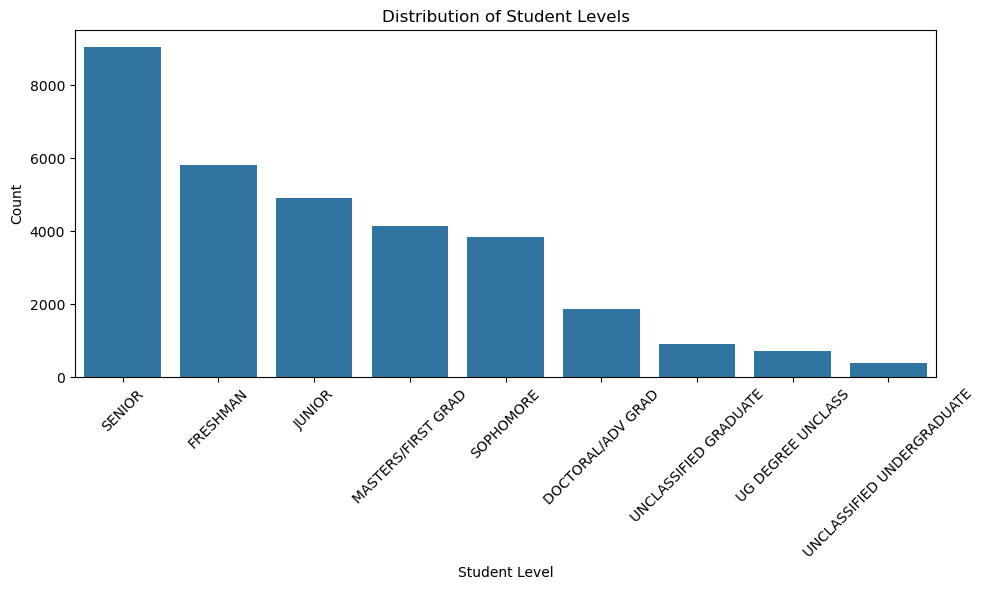

In [13]:
# Histogram for what class the student is in

plt.figure(figsize=(10, 6))
student_level_counts = data_2023['STUDENT_LEVL_DESC'].value_counts()
sb.barplot(x=student_level_counts.index, y=student_level_counts.values)
plt.title('Distribution of Student Levels')
plt.xlabel('Student Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

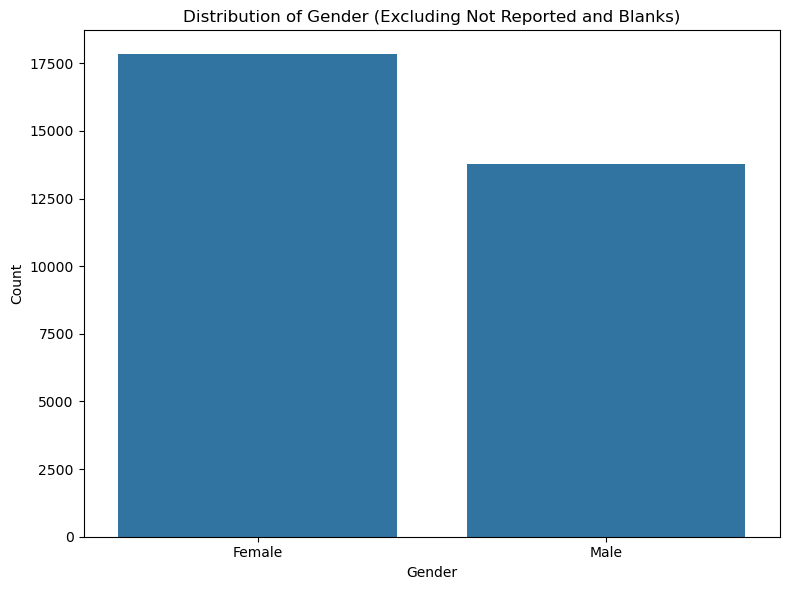

In [14]:
# Histogram for the Gender of the students

filtered_data = data_2023.copy()
plt.figure(figsize=(8, 6))
# Filter out "Not Reported" and blank/NaN values
# Filter out "Not Reported", empty strings, whitespace-only strings, and NaN values
filtered_data = filtered_data[
    ~filtered_data['GENDER_DESC'].isin(['Not Reported']) & 
    filtered_data['GENDER_DESC'].notna() &
    filtered_data['GENDER_DESC'].str.strip().astype(bool)  # This removes empty and whitespace-only strings
]

gender_counts = filtered_data['GENDER_DESC'].value_counts()
sb.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title('Distribution of Gender (Excluding Not Reported and Blanks)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

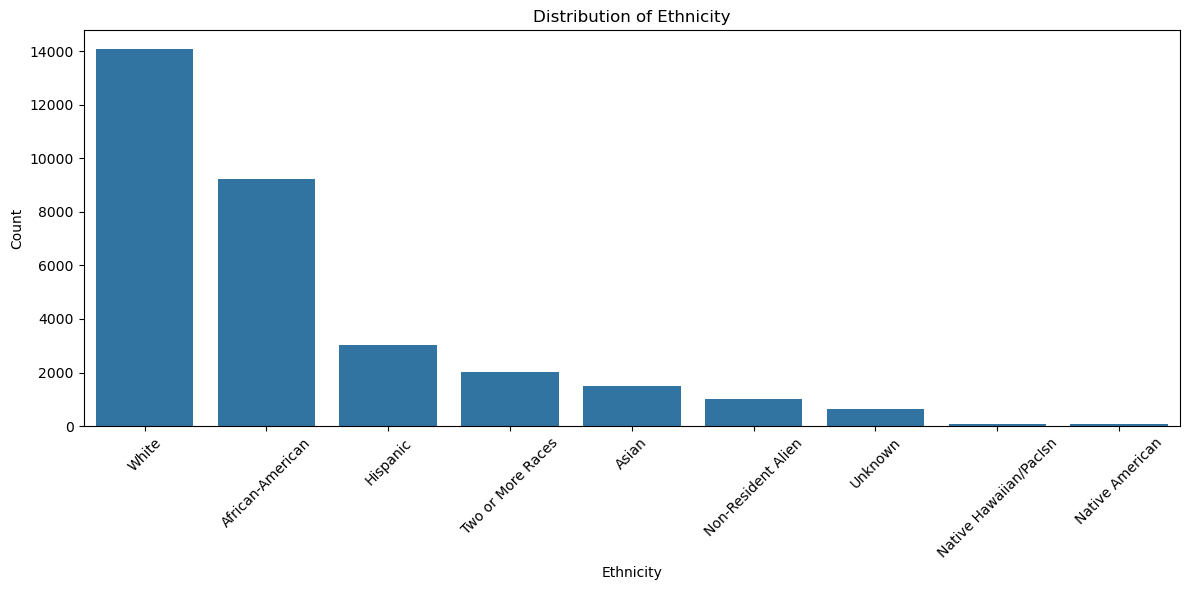

In [15]:
# Histogram for ethnicity of the student

plt.figure(figsize=(12, 6))
ethnicity_counts = data_2023['PRIMARY_ETHNICITY_DESC'].value_counts()
sb.barplot(x=ethnicity_counts.index, y=ethnicity_counts.values)
plt.title('Distribution of Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x labels for better readability
plt.tight_layout()
plt.show()

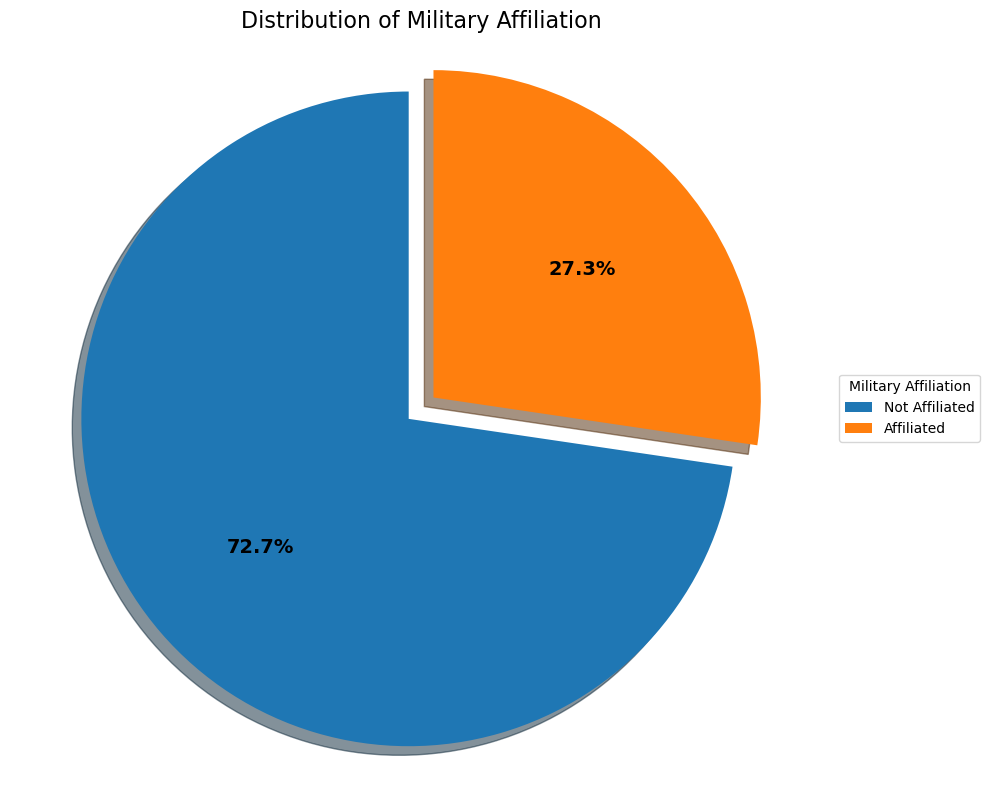

In [16]:
# Pie graph on Military Affiliation

military_counts = data_2023['MILITARY_AFFILIATED_IND'].value_counts()

label_mapping = {0: "Not Affiliated", 1: "Affiliated"}

custom_labels = [label_mapping.get(idx, str(idx)) for idx in military_counts.index]

plt.figure(figsize=(10, 8))
plt.pie(
    military_counts.values,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    startangle=90,      # Start angle for the pie chart
    shadow=True,        # Add shadow effect
    explode=[0.05] * len(military_counts),  # Slightly explode all slices for better visibility - ADDED COMMA HERE
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

# Add a legend with custom labels
plt.legend(custom_labels, title="Military Affiliation", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Add a title
plt.title('Distribution of Military Affiliation', fontsize=16)

# Ensure the pie chart is drawn as a circle
plt.axis('equal')

# Show the plot
plt.tight_layout()
plt.show()

C:\Users\dunca\AppData\Local\Temp\ipykernel_37024\1164325290.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


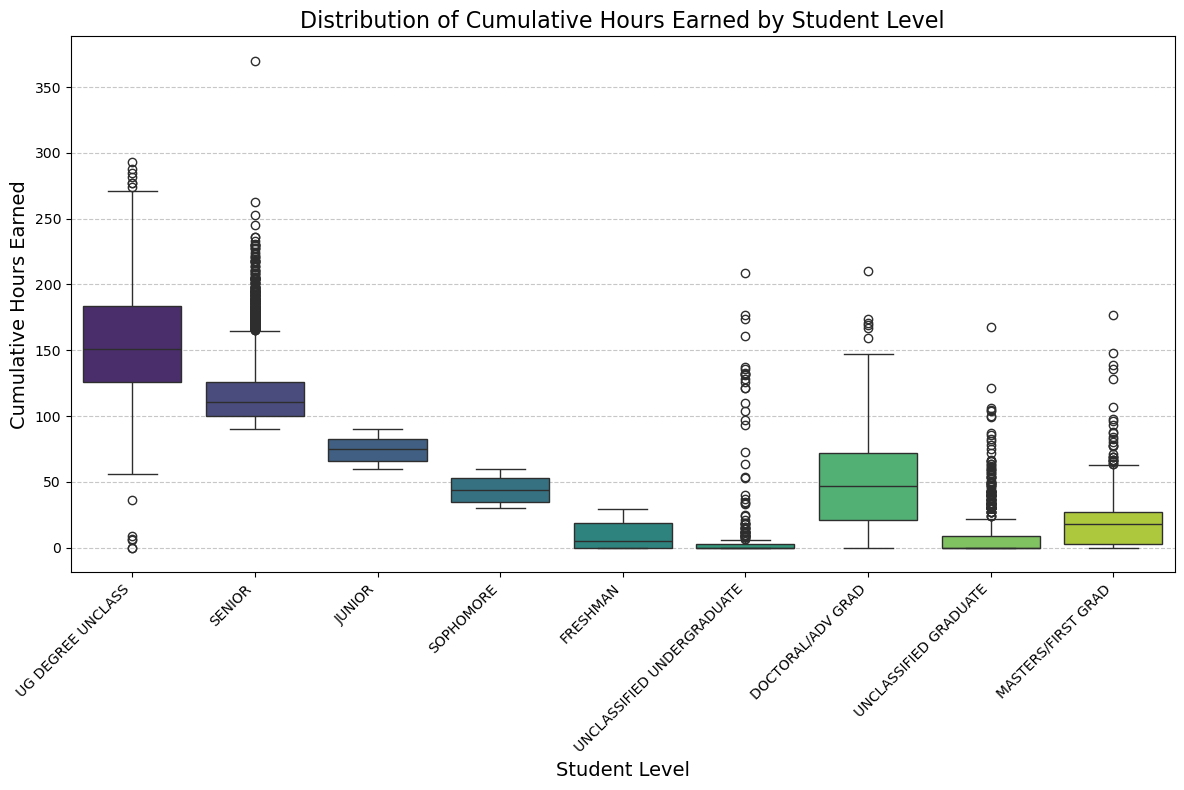

In [17]:
# Import necessary libraries if not already imported
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot showing the distribution of cumulative hours earned by student level
plt.figure(figsize=(12, 8))  # Set figure size for better visibility

# Create the box plot using seaborn
sb.boxplot(
    x='STUDENT_LEVL_DESC',  # Categories on x-axis (student level)
    y='CUML_HRS_EARN_TOTL',  # Values on y-axis (cumulative hours earned)
    data=data_2023,  # Your dataframe
    palette='viridis'  # Color palette for visual appeal
)

# Add title and labels
plt.title('Distribution of Cumulative Hours Earned by Student Level', fontsize=16)
plt.xlabel('Student Level', fontsize=14)
plt.ylabel('Cumulative Hours Earned', fontsize=14)

# Rotate x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

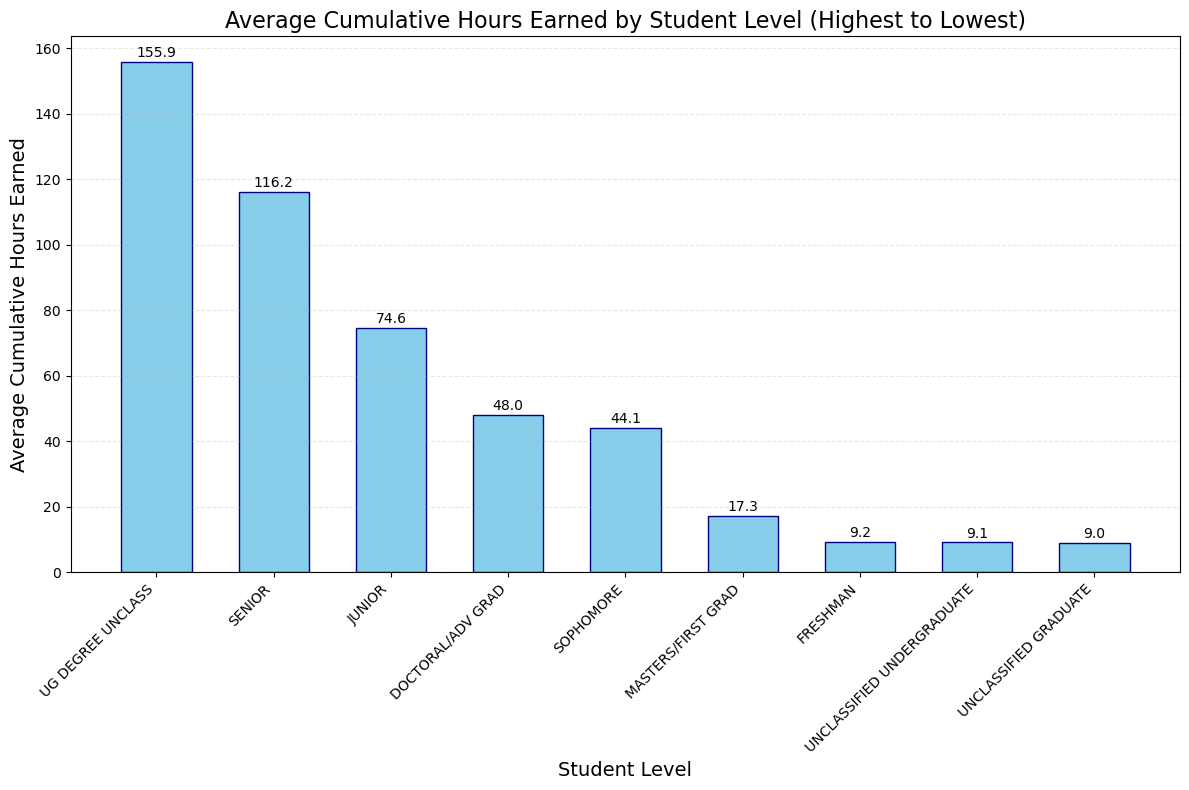

In [18]:
# Calculate the average cumulative hours earned for each student level
avg_hours_by_level = data_2023.groupby('STUDENT_LEVL_DESC')['CUML_HRS_EARN_TOTL'].mean().reset_index()

# Sort the dataframe by average hours in descending order
avg_hours_by_level = avg_hours_by_level.sort_values('CUML_HRS_EARN_TOTL', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 8))

# Create the bar plot with sorted data
bars = plt.bar(
    avg_hours_by_level['STUDENT_LEVL_DESC'],
    avg_hours_by_level['CUML_HRS_EARN_TOTL'],
    color='skyblue',
    edgecolor='navy',
    width=0.6
)

# Add title and labels
plt.title('Average Cumulative Hours Earned by Student Level (Highest to Lowest)', fontsize=16)
plt.xlabel('Student Level', fontsize=14)
plt.ylabel('Average Cumulative Hours Earned', fontsize=14)

# Rotate x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

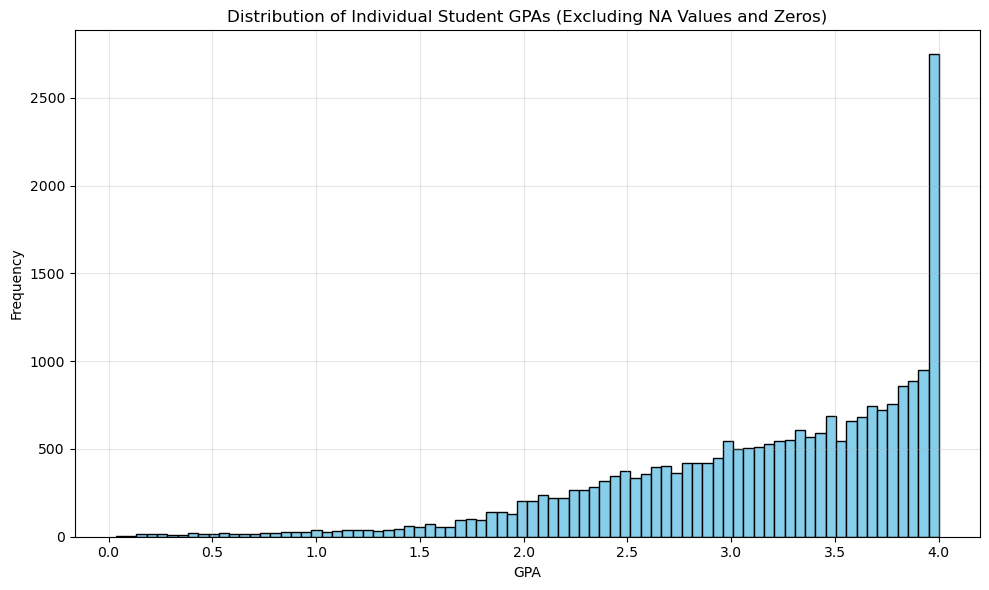

In [22]:
plt.figure(figsize=(10, 6))
# Create a dataset with all student records
GPA_unique_overall = data_2023
# Remove NA values AND zeros from the GPA column before plotting
# This filters out zeros which would create a large bar at 0 in the histogram
GPA_clean_overall = GPA_unique_overall[(GPA_unique_overall['CUML_GPA_TOTL'].notna()) & (GPA_unique_overall['CUML_GPA_TOTL'] > 0)]
# Create histogram using the cleaned dataset
plt.hist(GPA_clean_overall['CUML_GPA_TOTL'], bins=80, color='skyblue', edgecolor='black')
plt.title('Distribution of Individual Student GPAs (Excluding NA Values and Zeros)')
plt.xlabel('GPA')  # X-axis label
plt.ylabel('Frequency')  # Y-axis label
plt.grid(True, alpha=0.3)  # Add light grid lines for better readability
plt.tight_layout()  # Adjust padding to ensure everything fits without overlap
plt.show() 

In [5]:
data_wellness = pd.read_excel("C:\\Users\\dunca\\OneDrive\\Desktop\\DASC 690\\DATA\\SEES COMBO.xlsx")

data_wellness.head()

,Event Name,Date of Event,Academic Period,UIN,SEES Department,SEES Sub Department,Retention Outreach Indicator,HEP Indicator,4+ Events Indicator,Student Risk Factor,...,UIN Count per dept,Total Swipes per Term,Ethnicity,Military Affiliation,Age,GPA_Prior,GPA_Current,GPA_Cumulative,Class Level,Class
0,SRC_Entrances,2022-11-02,Fall 2022,49874,Recreation & Wellness,Membership,N,N,N,NaN,...,7,7,White,0.0,36.0,3.925,NaN,3.975,UG,SENIOR
1,SRC_Entrances,2022-12-06,Fall 2022,49874,Recreation & Wellness,Membership,N,N,N,NaN,...,7,7,White,0.0,36.0,3.925,NaN,3.975,UG,SENIOR
2,SRC_Entrances,2022-09-19,Fall 2022,49874,Recreation & Wellness,Membership,N,N,N,NaN,...,7,7,White,0.0,36.0,3.925,NaN,3.975,UG,SENIOR
3,SRC_Entrances,2022-09-21,Fall 2022,49874,Recreation & Wellness,Membership,N,N,N,NaN,...,7,7,White,0.0,36.0,3.925,NaN,3.975,UG,SENIOR
4,SRC_Entrances,2022-09-26,Fall 2022,49874,Recreation & Wellness,Membership,N,N,N,NaN,...,7,7,White,0.0,36.0,3.925,NaN,3.975,UG,SENIOR


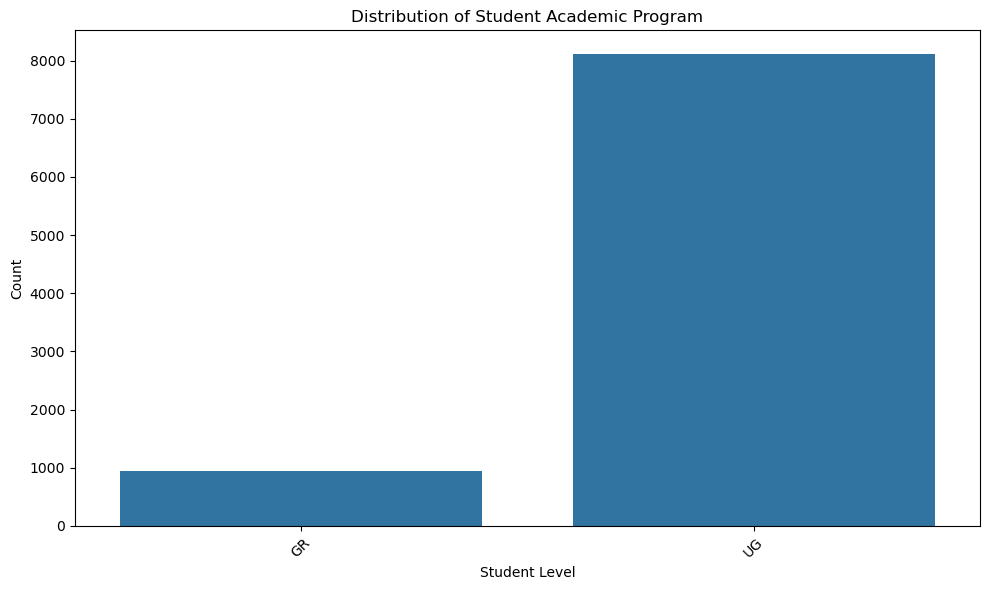

In [5]:
plt.figure(figsize=(10, 6))
student_level_counts = data_wellness.groupby('Class Level')['UIN'].nunique()
sb.barplot(x=student_level_counts.index, y=student_level_counts.values)
plt.title('Distribution of Student Academic Program')
plt.xlabel('Student Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

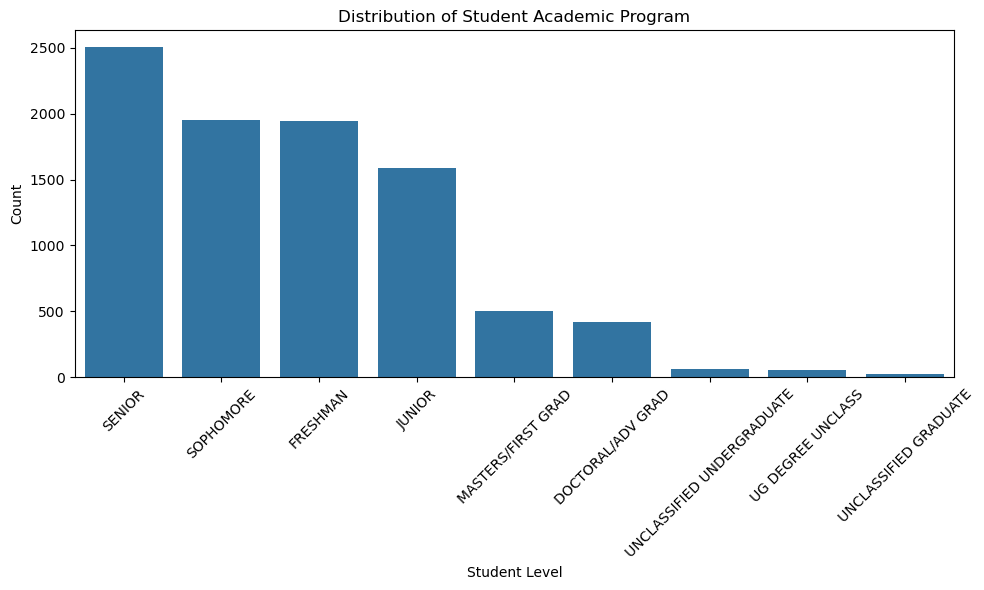

In [23]:
# Create a figure with specified size (10x6 inches)
plt.figure(figsize=(10, 6))

# Count unique student IDs (UINs) grouped by their academic class/level
student_level_counts = data_wellness.groupby('Class')['UIN'].nunique()

# Sort the counts in descending order
student_level_counts = student_level_counts.sort_values(ascending=False)

# Create a bar plot showing the distribution of students across academic programs in descending order
sb.barplot(x=student_level_counts.index, y=student_level_counts.values)

# Add title and axis labels to the plot
plt.title('Distribution of Student Academic Program')
plt.xlabel('Student Level')
plt.ylabel('Count')

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Adjust layout to ensure all elements fit within the figure area
plt.tight_layout()

# Display the plot
plt.show()

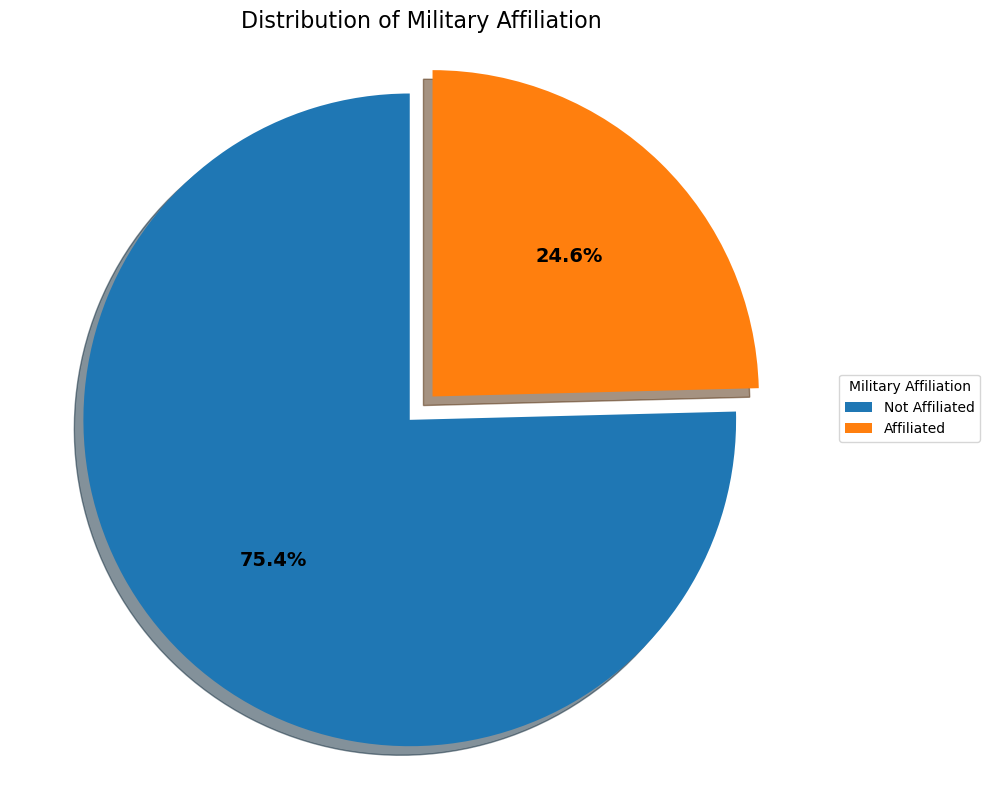

In [9]:
military_wellness = data_wellness.groupby('Military Affiliation')['UIN'].nunique()

label_mapping = {0: "Not Affiliated", 1: "Affiliated"}

custom_labels = [label_mapping.get(idx, str(idx)) for idx in military_wellness.index]

plt.figure(figsize=(10, 8))
plt.pie(
    military_wellness.values,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    startangle=90,      # Start angle for the pie chart
    shadow=True,        # Add shadow effect
    explode=[0.05] * len(military_wellness),  # Slightly explode all slices for better visibility - ADDED COMMA HERE
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

# Add a legend with custom labels
plt.legend(custom_labels, title="Military Affiliation", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Add a title
plt.title('Distribution of Military Affiliation', fontsize=16)

# Ensure the pie chart is drawn as a circle
plt.axis('equal')

# Show the plot
plt.tight_layout()
plt.show()

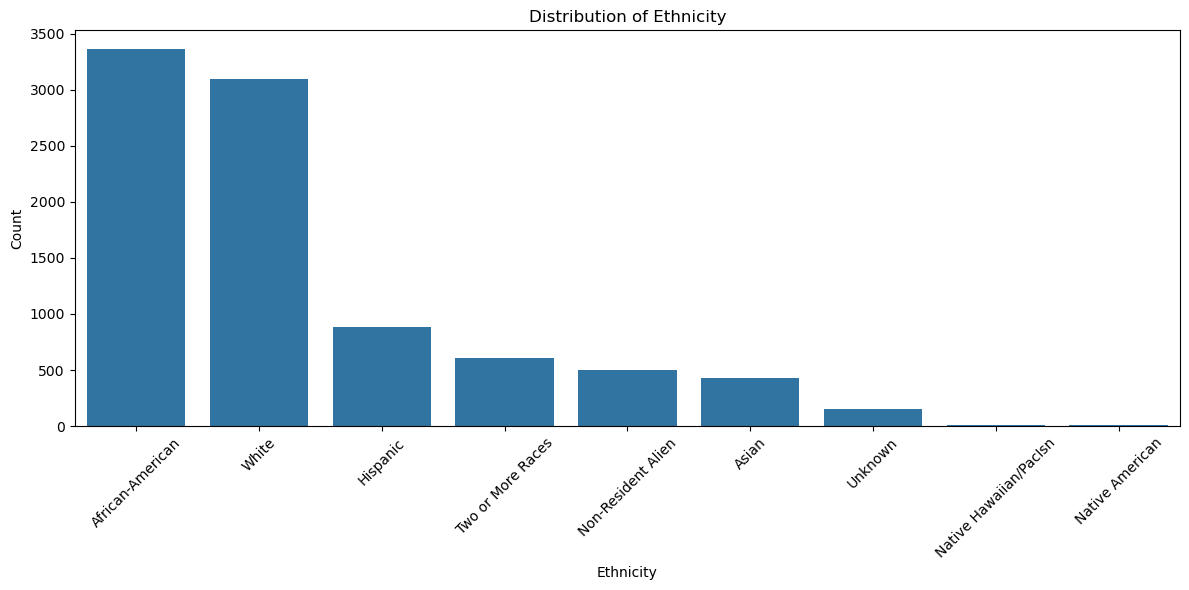

In [11]:
plt.figure(figsize=(12, 6))
ethnicity_wellness = data_wellness.groupby('Ethnicity')['UIN'].nunique()
ethnicity_wellness = ethnicity_wellness.sort_values(ascending=False)
sb.barplot(x=ethnicity_wellness.index, y=ethnicity_wellness.values)
plt.title('Distribution of Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x labels for better readability
plt.tight_layout()
plt.show()

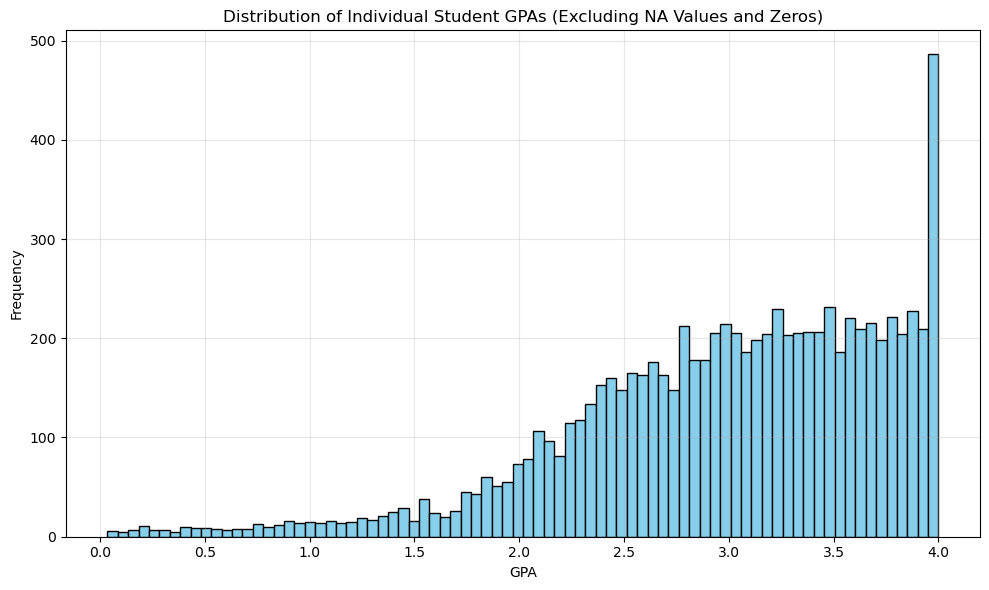

In [18]:
plt.figure(figsize=(10, 6))
# First create a dataset with only unique students
GPA_unique = data_wellness.drop_duplicates(subset=['UIN'])
# Remove NA values AND zeros from the GPA column before plotting
GPA_clean = GPA_unique[(GPA_unique['GPA_Cumulative'].notna()) & (GPA_unique['GPA_Cumulative'] > 0)]
# Create histogram using the cleaned dataset
plt.hist(GPA_clean['GPA_Cumulative'], bins=80, color='skyblue', edgecolor='black')
plt.title('Distribution of Individual Student GPAs (Excluding NA Values and Zeros)')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

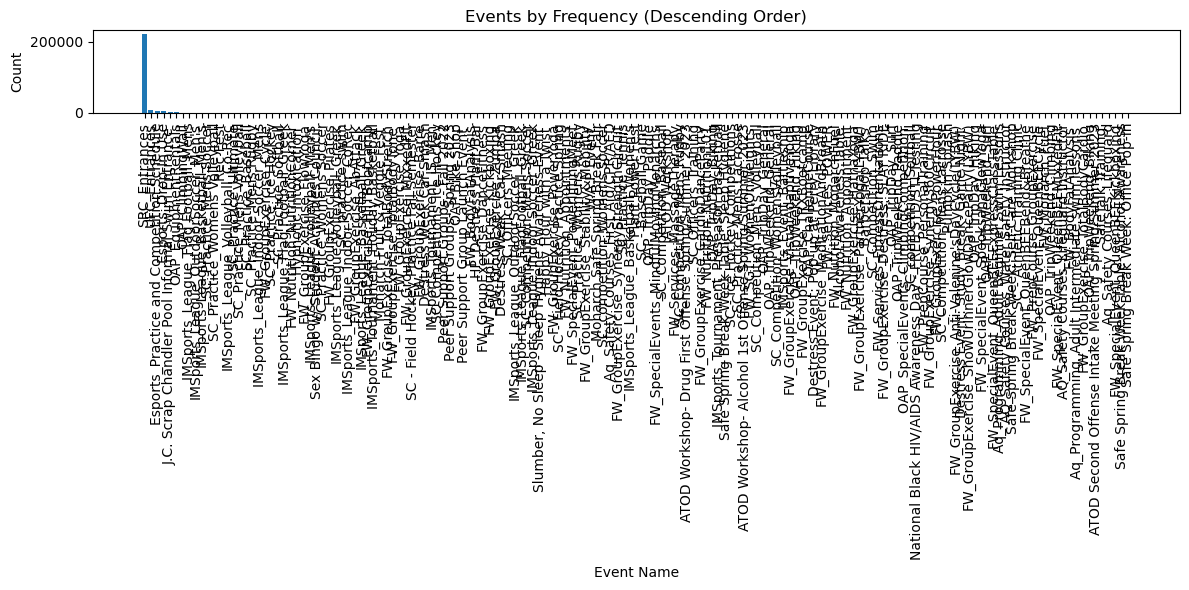

In [26]:
event_counts = data_wellness['Event Name'].value_counts()

# Create the bar plot with counts in descending order
plt.figure(figsize=(12, 6))
plt.bar(event_counts.index, event_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Event Name')
plt.ylabel('Count')
plt.title('Events by Frequency (Descending Order)')
plt.tight_layout()
plt.show()

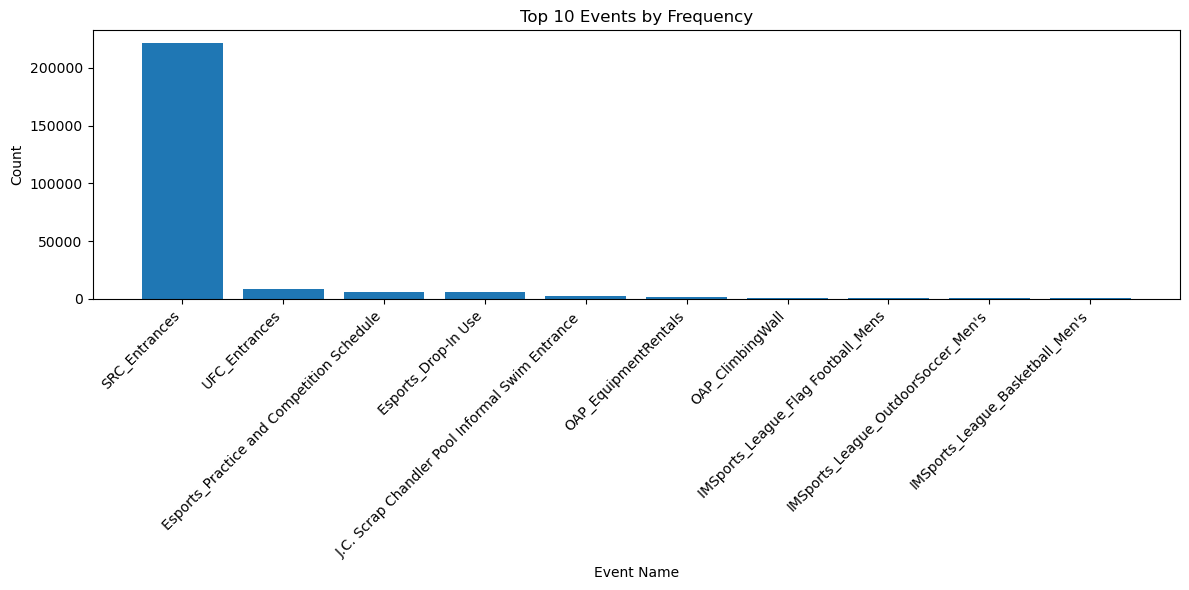

In [27]:
top_events = data_wellness['Event Name'].value_counts().nlargest(10)

# Create the bar plot with the top 10 events in descending order
plt.figure(figsize=(12, 6))
plt.bar(top_events.index, top_events.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Event Name')
plt.ylabel('Count')
plt.title('Top 10 Events by Frequency')
plt.tight_layout()
plt.show()

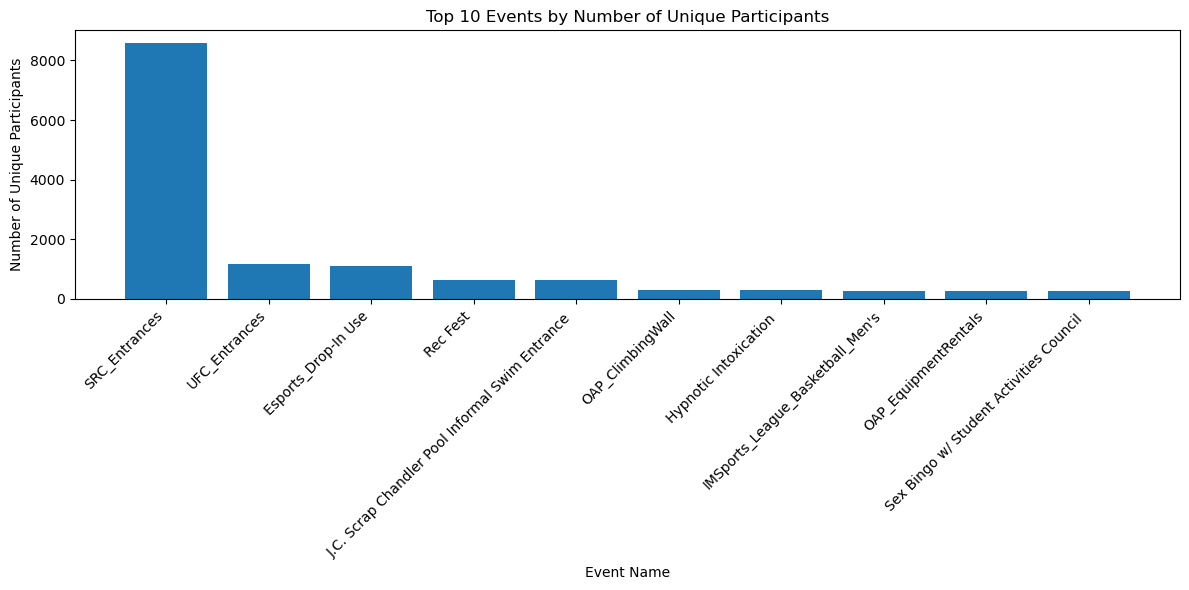

In [28]:
# Count unique UINs for each event and get the top 10 events with most unique participants
top_events = data_wellness.groupby('Event Name')['UIN'].nunique().nlargest(10)

# Create the bar plot with the top 10 events in descending order
plt.figure(figsize=(12, 6))  # Set figure size to 12x6 inches
plt.bar(top_events.index, top_events.values)  # Create bar chart with event names as x-axis and unique UIN counts as y-axis
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels 45 degrees and align them to the right
plt.xlabel('Event Name')  # Label for x-axis
plt.ylabel('Number of Unique Participants')  # Label for y-axis
plt.title('Top 10 Events by Number of Unique Participants')  # Add title to the plot
plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show() 

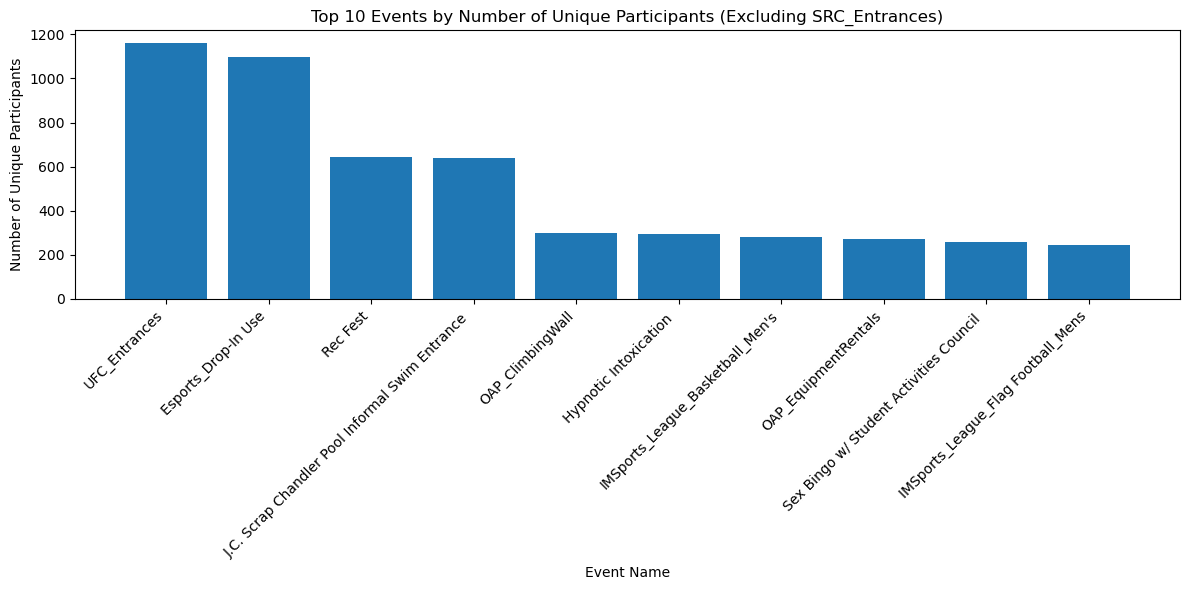

In [6]:
# Filter out "SRC_Entrances" from the data
filtered_data = data_wellness[data_wellness['Event Name'] != 'SRC_Entrances']

# Count unique UINs for each event and get the top 10 events with most unique participants
top_events = filtered_data.groupby('Event Name')['UIN'].nunique().nlargest(10)

# Create the bar plot with the top 10 events in descending order
plt.figure(figsize=(12, 6))  # Set figure size to 12x6 inches
plt.bar(top_events.index, top_events.values)  # Create bar chart with event names as x-axis and unique UIN counts as y-axis
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels 45 degrees and align them to the right
plt.xlabel('Event Name')  # Label for x-axis
plt.ylabel('Number of Unique Participants')  # Label for y-axis
plt.title('Top 10 Events by Number of Unique Participants (Excluding SRC_Entrances)')  # Add title to the plot
plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()  # Display the plot

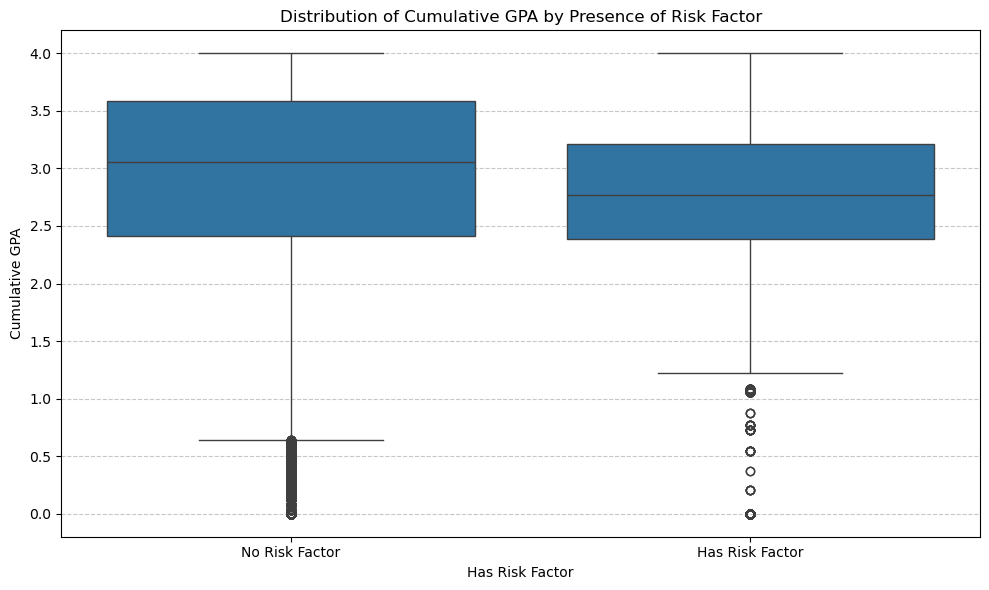

In [8]:
# Create a new column to identify if Student Risk Factor is blank or not
data_wellness['Has_Risk_Factor'] = data_wellness['Student Risk Factor'].notna()

# Create the figure for the box plot
plt.figure(figsize=(10, 6))

# Create box plot comparing GPA_Cumulative between those with and without risk factors
sb.boxplot(x='Has_Risk_Factor', y='GPA_Cumulative', data=data_wellness)

# Add labels and title
plt.xlabel('Has Risk Factor')
plt.ylabel('Cumulative GPA')
plt.title('Distribution of Cumulative GPA by Presence of Risk Factor')

# Improve x-axis labels
plt.xticks([0, 1], ['No Risk Factor', 'Has Risk Factor'])

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

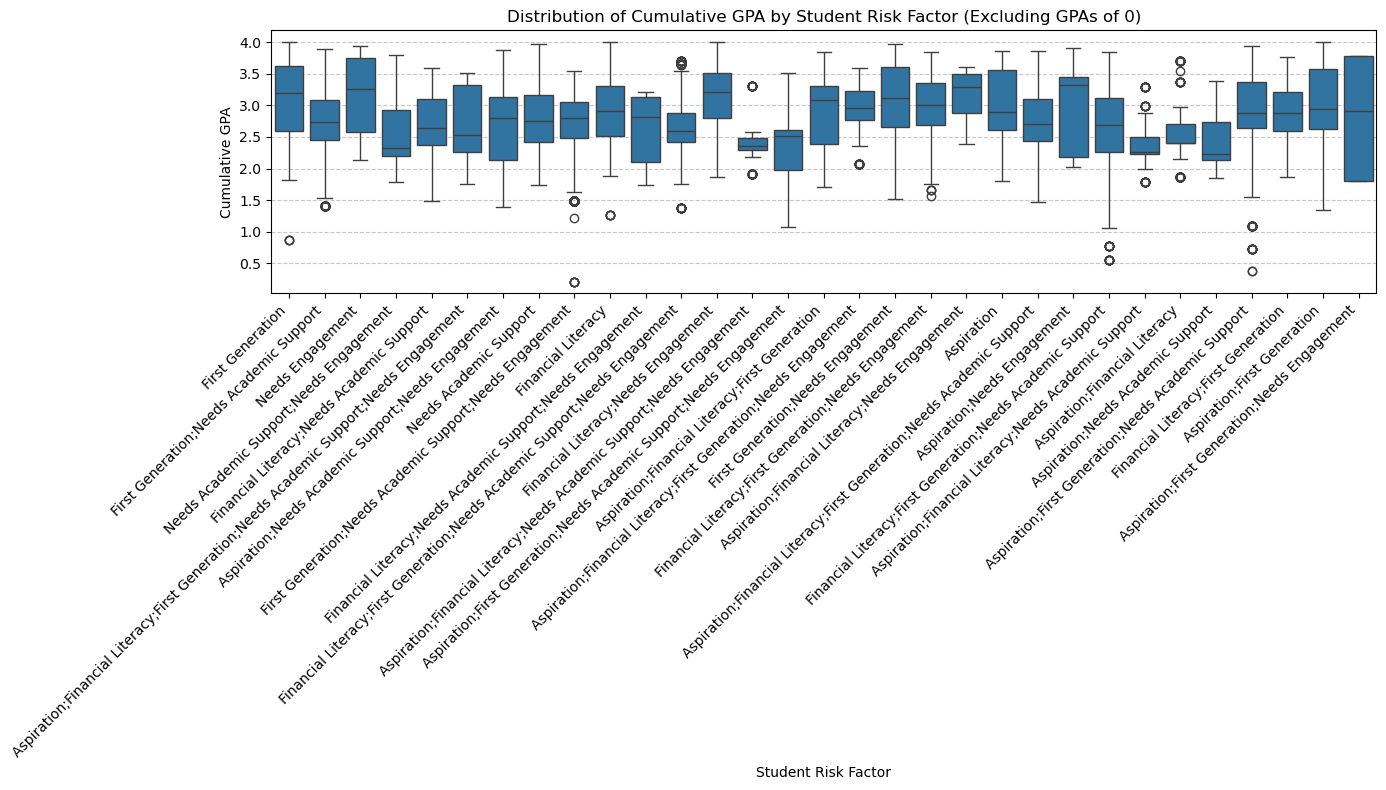

In [12]:
# Drop rows with missing risk factors and filter out GPA values of 0
risk_data = data_wellness.dropna(subset=['Student Risk Factor'])
risk_data = risk_data[risk_data['GPA_Cumulative'] > 0]

# Create the figure for the box plot
plt.figure(figsize=(14, 8))

# Create box plot comparing GPA_Cumulative across different risk factors
sb.boxplot(x='Student Risk Factor', y='GPA_Cumulative', data=risk_data)

# Add labels and title
plt.xlabel('Student Risk Factor')
plt.ylabel('Cumulative GPA')
plt.title('Distribution of Cumulative GPA by Student Risk Factor (Excluding GPAs of 0)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

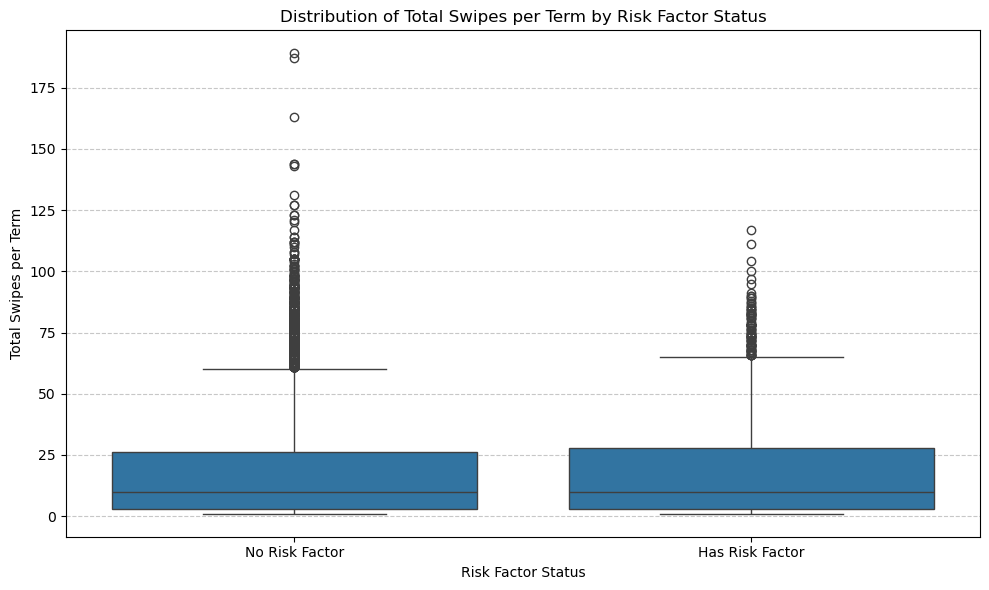

In [14]:
# Create a new column to identify if Student Risk Factor is blank or not
data_wellness['Has_Risk_Factor'] = data_wellness['Student Risk Factor'].notna()

# Group by UIN and Term, count swipes, then group by Has_Risk_Factor to get distribution
swipes_per_term = data_wellness.groupby(['UIN', 'Total Swipes per Term', 'Has_Risk_Factor']).size().reset_index(name='Swipes')
swipes_distribution = swipes_per_term.groupby('Has_Risk_Factor')['Swipes']

# Create the figure for the box plot
plt.figure(figsize=(10, 6))

# Create box plot comparing swipes per term between those with and without risk factors
sb.boxplot(x='Has_Risk_Factor', y='Swipes', data=swipes_per_term)

# Add labels and title
plt.xlabel('Risk Factor Status')
plt.ylabel('Total Swipes per Term')
plt.title('Distribution of Total Swipes per Term by Risk Factor Status')

# Improve x-axis labels
plt.xticks([0, 1], ['No Risk Factor', 'Has Risk Factor'])

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

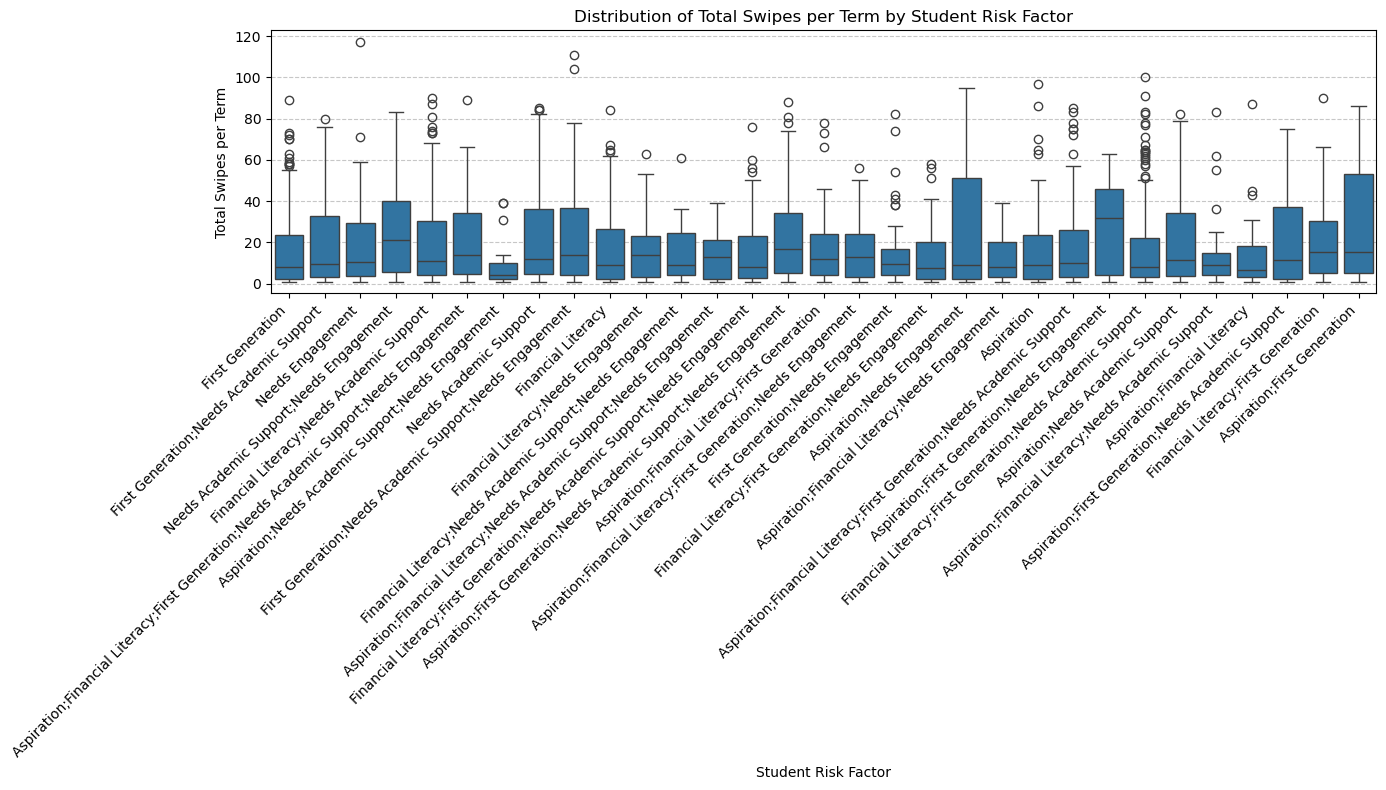

In [16]:
# Drop rows with missing risk factors
risk_data = data_wellness.dropna(subset=['Student Risk Factor'])

# Group by UIN, Term, and Student Risk Factor, count swipes
swipes_per_term = risk_data.groupby(['UIN', 'Total Swipes per Term', 'Student Risk Factor']).size().reset_index(name='Swipes')

# Create the figure for the box plot
plt.figure(figsize=(14, 8))

# Create box plot comparing swipes per term across different risk factors
sb.boxplot(x='Student Risk Factor', y='Swipes', data=swipes_per_term)

# Add labels and title
plt.xlabel('Student Risk Factor')
plt.ylabel('Total Swipes per Term')
plt.title('Distribution of Total Swipes per Term by Student Risk Factor')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()